In [9]:
#Load the Dataset
import pandas as pd
data = pd.read_csv("Retail and wherehouse Sale - Retail and wherehouse Sale.csv")
print(data)

       YEAR  MONTH                              SUPPLIER ITEM CODE  \
0      2020      1     REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1      2020      1                             PWSWN INC    100024   
2      2020      1               RELIABLE CHURCHILL LLLP      1001   
3      2020      1             LANTERNA DISTRIBUTORS INC    100145   
4      2020      1                  DIONYSOS IMPORTS INC    100293   
...     ...    ...                                   ...       ...   
29995  2020      3  THE COUNTRY VINTNER, LLC DBA WINEBOW    352322   
29996  2020      3                       OSLO ENTERPRISE    352324   
29997  2020      3       OPICI FAMILY DISTRIBUTING OF MD    352354   
29998  2020      3                   CAMPARI AMERICA LLC     35238   
29999  2020      3  THE COUNTRY VINTNER, LLC DBA WINEBOW    352380   

                            ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                        BOOTLEG RED - 750ML      WINE          0.00   
1              

In [10]:
#Display First Five Records and Dataset Size
print("First Five Records:")
print(data.head())

print("\nNumber of Rows:", data.shape[0])
print("Number of Columns:", data.shape[1])

First Five Records:
   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0               0.0              2.0  
1               1.0              4.0  
2               0.0              1.0  
3               0.0              1.0  
4        

In [11]:
#Display Column Names and Data Types
print("Column Names:")
print(data.columns)

print("\nData Types:")
print(data.dtypes)

Column Names:
Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='str')

Data Types:
YEAR                  int64
MONTH                 int64
SUPPLIER                str
ITEM CODE               str
ITEM DESCRIPTION        str
ITEM TYPE               str
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object


In [13]:
#Check Missing Values and Duplicate Records
print("Missing Values:")
print(data.isnull().sum())

print("\nDuplicate Records:")
print(data.duplicated().sum())

Missing Values:
YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

Duplicate Records:
0


In [14]:
#Display Different ITEM TYPE Categories
print("Different ITEM TYPE Categories:")
print(data["ITEM TYPE"].unique())

Different ITEM TYPE Categories:
<StringArray>
[        'WINE',         'BEER',       'LIQUOR', 'STR_SUPPLIES',
         'KEGS',          'REF',      'DUNNAGE',  'NON-ALCOHOL']
Length: 8, dtype: str


In [15]:
#Calculate Average RETAIL SALES for Each ITEM TYPE
average_sales = data.groupby("ITEM TYPE")["RETAIL SALES"].mean()

print("Average Retail Sales:")
print(average_sales)

Average Retail Sales:
ITEM TYPE
BEER            14.118748
DUNNAGE          0.000000
KEGS             0.000000
LIQUOR          13.635171
NON-ALCOHOL     31.742419
REF              5.783750
STR_SUPPLIES     5.485714
WINE             3.195334
Name: RETAIL SALES, dtype: float64


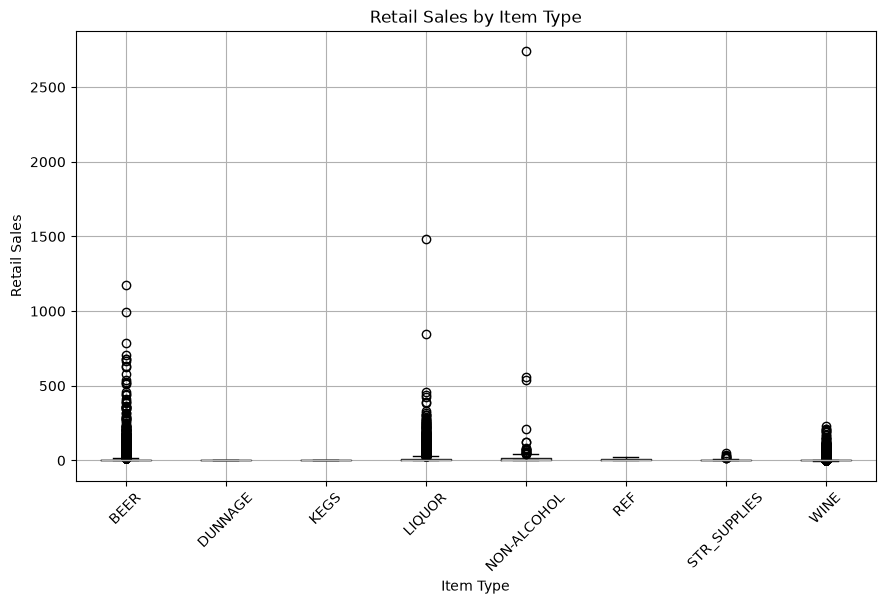

In [16]:
#Create Box Plot
import matplotlib.pyplot as plt

data.boxplot(column="RETAIL SALES", by="ITEM TYPE", figsize=(10, 6))

plt.xlabel("Item Type")
plt.ylabel("Retail Sales")
plt.title("Retail Sales by Item Type")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Hypotheses
# Null Hypothesis (H₀):
# The average retail sales are equal for all item types.

# Alternative Hypothesis (H₁):
# The average retail sales are different for at least one item type.

In [18]:
#Perform One-Way ANOVA
from scipy.stats import f_oneway

groups = [
    group["RETAIL SALES"].dropna()
    for name, group in data.groupby("ITEM TYPE")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)


F-statistic: 123.52155338346161
p-value: 8.68562909538067e-180


In [19]:
#Display F-Statistic and p-Value
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 123.52155338346161
p-value: 8.68562909538067e-180


In [20]:
#Compare p-Value with 0.05
if p_value < 0.05:
    print("p-value is less than 0.05")
else:
    print("p-value is greater than or equal to 0.05")

p-value is less than 0.05


In [21]:
#Decision About Null Hypothesis
if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Do Not Reject the Null Hypothesis")

Reject the Null Hypothesis


In [ ]:
# Conclusion

# The ANOVA analysis determines whether there is a significant difference in average retail sales among different item types.
#  If the p-value is less than 0.05, the null hypothesis is rejected, showing a significant difference in sales.


Part B: Factorial Experiment

In [22]:
#Select ITEM TYPE and YEAR
item_type = data["ITEM TYPE"]
year = data["YEAR"]
retail_sales = data["RETAIL SALES"]

print("Factors:")
print("1. ITEM TYPE")
print("2. YEAR")

print("\nResponse Variable:")
print("RETAIL SALES")

Factors:
1. ITEM TYPE
2. YEAR

Response Variable:
RETAIL SALES


In [23]:
#Average Retail Sales for ITEM TYPE and YEAR
average_combination = data.groupby(
    ["ITEM TYPE", "YEAR"]
)["RETAIL SALES"].mean()

print(average_combination)

ITEM TYPE     YEAR
BEER          2020    14.118748
DUNNAGE       2020     0.000000
KEGS          2020     0.000000
LIQUOR        2020    13.635171
NON-ALCOHOL   2020    31.742419
REF           2020     5.783750
STR_SUPPLIES  2020     5.485714
WINE          2020     3.195334
Name: RETAIL SALES, dtype: float64


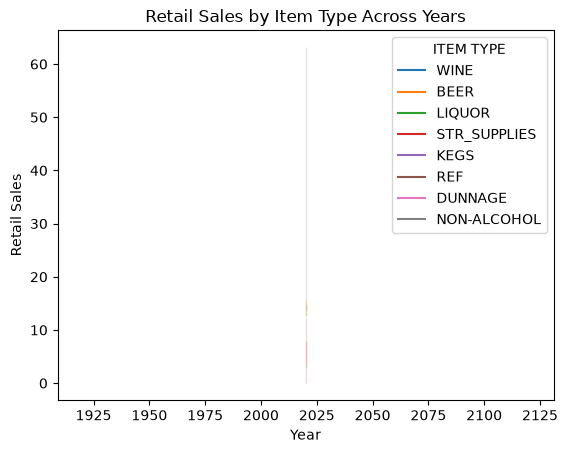

In [24]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=data,
    x="YEAR",
    y="RETAIL SALES",
    hue="ITEM TYPE"
)

plt.title("Retail Sales by Item Type Across Years")
plt.xlabel("Year")
plt.ylabel("Retail Sales")
plt.show()

In [25]:
#Main Effect of ITEM TYPE
item_effect = data.groupby("ITEM TYPE")["RETAIL SALES"].mean()

print("Main Effect of ITEM TYPE:")
print(item_effect)

Main Effect of ITEM TYPE:
ITEM TYPE
BEER            14.118748
DUNNAGE          0.000000
KEGS             0.000000
LIQUOR          13.635171
NON-ALCOHOL     31.742419
REF              5.783750
STR_SUPPLIES     5.485714
WINE             3.195334
Name: RETAIL SALES, dtype: float64


In [26]:
#Main Effect of YEAR
year_effect = data.groupby("YEAR")["RETAIL SALES"].mean()

print("Main Effect of YEAR:")
print(year_effect)

Main Effect of YEAR:
YEAR
2020    6.939796
Name: RETAIL SALES, dtype: float64


In [27]:
#Interaction Effect
interaction = data.groupby(
    ["ITEM TYPE", "YEAR"]
)["RETAIL SALES"].mean()

print("Interaction Effect:")
print(interaction)

Interaction Effect:
ITEM TYPE     YEAR
BEER          2020    14.118748
DUNNAGE       2020     0.000000
KEGS          2020     0.000000
LIQUOR        2020    13.635171
NON-ALCOHOL   2020    31.742419
REF           2020     5.783750
STR_SUPPLIES  2020     5.485714
WINE          2020     3.195334
Name: RETAIL SALES, dtype: float64


In [32]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("Q('RETAIL SALES') ~ C(Q('ITEM TYPE'))", data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                         sum_sq       df           F         PR(>F)
C(Q('ITEM TYPE'))  9.199348e+05      7.0  123.521553  8.685629e-180
Residual           3.190856e+07  29991.0         NaN            NaN


In [33]:
#Display Statistical Results and p-Values
print("Factorial ANOVA Results:")
print(anova_table)

print("\nP-values:")
print(anova_table["PR(>F)"])

Factorial ANOVA Results:
                         sum_sq       df           F         PR(>F)
C(Q('ITEM TYPE'))  9.199348e+05      7.0  123.521553  8.685629e-180
Residual           3.190856e+07  29991.0         NaN            NaN

P-values:
C(Q('ITEM TYPE'))    8.685629e-180
Residual                       NaN
Name: PR(>F), dtype: float64


In [34]:
#Identify Significant Effects
print("Significance at 0.05 level:")

for effect, p in anova_table["PR(>F)"].items():
    if p < 0.05:
        print(effect, ": Significant")
    else:
        print(effect, ": Not Significant")

Significance at 0.05 level:
C(Q('ITEM TYPE')) : Significant
Residual : Not Significant


In [ ]:
# Final Business Conclusion

# The analysis shows that ITEM TYPE has an effect on retail sales. Different product categories have different average sales, which can help the business identify products with higher sales and make better inventory and sales decisions. 
# Since the dataset contains only the year 2020, the effect of YEAR and the ITEM TYPE × YEAR interaction cannot be analyzed.